In [61]:
def Luasan_PV(x):
    """Menghitung Luasan PV"""
    # Untuk Luasan 'Sedikit'
    luas_sedikit = max(0, (50 - x) / 50) if x < 50 else 0

    # Untuk Luasan 'Sedang'
    if 0 <= x <= 50:
        luas_sedang = x / 50
    elif 50 < x < 100:
        luas_sedang = (100 - x) / 50
    else:
        luas_sedang = 0

    # Untuk Luasan 'Banyak'
    luas_banyak = max(0, (x - 50) / 50) if x > 50 else 0
    if x >= 100:
        luas_banyak = 1

    return luas_sedikit, luas_sedang, luas_banyak

def daya_PV(y):
    """Menghitung Daya PV"""
    # Daya 'Kecil'
    daya_kecil = max(0, (5 - y) / 5) if y < 5 else 0

    # Daya 'Menengah'
    if 0 <= y <= 5:
        daya_menengah = y / 5
    elif 5 < y < 10:
        daya_menengah = (10 - y) / 5
    else:
        daya_menengah = 0

    # Daya 'Besar'
    daya_besar = max(0, (y - 5) / 5) if y > 5 else 0
    if y >= 10:
        daya_besar = 1

    return daya_kecil, daya_menengah, daya_besar

In [62]:
def fuzzy_pv(luasan, daya):
    # 1. Fuzzifikasi
    luas_sedikit, luas_sedang, luas_banyak = Luasan_PV(luasan)
    daya_kecil, daya_menengah, daya_besar = daya_PV(daya)

    # 2. Nilai Singleton Output
    BASIC = 15
    PREMIUM = 30
    PLATINUM = 50

    # 3.Array dan Matriks Aturan
    array_luasan = [luas_sedikit, luas_sedang, luas_banyak]
    array_daya = [daya_kecil, daya_menengah, daya_besar]

    # Matriks Aturan
    tabel_aturan = [
        [BASIC, BASIC, PREMIUM],
        [BASIC, PREMIUM, PLATINUM],
        [PREMIUM, PLATINUM, PLATINUM]
    ]

    # Variabel penampung untuk Defuzzifikasi
    num = 0
    denum = 0

    print("--- = Aturan ---")
    # 4. Aturan & Defuzzifikasi secara bersamaan
    for i in range(len(array_luasan)):
        for j in range(len(array_daya)):

            # Nilai firing strength (Alpha) dengan fungsi AND (MIN)
            alpha = min(array_luasan[i], array_daya[j])

            # Ambil nilai Z (Target Paket) dari tabel matriks
            z = tabel_aturan[i][j]

            # Kalkulasi Weighted Average
            num += (alpha * z)
            denum += alpha

            # Print tabel evaluasi per aturan
            print(f"R{i*3 + j + 1} | Alpha: {alpha:.2f} | Z Output: {z}")

    # 5. Menghitung Hasil Akhir
    if denum == 0:
        return 0

    hasil_estimasi = num / denum
    return hasil_estimasi

# ==========================================
# TEST SCRIPT
# ==========================================
if __name__ == "__main__":
    test_luasan = 40
    test_daya = 6

    print(f"Input: Luasan = {test_luasan} m^2, Daya = {test_daya} kWp\n")
    harga = fuzzy_pv(test_luasan, test_daya)

    print("\n--- Kesimpulan ---")
    print(f"Estimasi Harga Paket: Rp {harga:.2f} Juta")

Input: Luasan = 40 m^2, Daya = 6 kWp

--- = Aturan ---
R1 | Alpha: 0.00 | Z Output: 15
R2 | Alpha: 0.20 | Z Output: 15
R3 | Alpha: 0.20 | Z Output: 30
R4 | Alpha: 0.00 | Z Output: 15
R5 | Alpha: 0.80 | Z Output: 30
R6 | Alpha: 0.20 | Z Output: 50
R7 | Alpha: 0.00 | Z Output: 30
R8 | Alpha: 0.00 | Z Output: 50
R9 | Alpha: 0.00 | Z Output: 50

--- Kesimpulan ---
Estimasi Harga Paket: Rp 30.71 Juta


In [63]:
import matplotlib.pyplot as plt
import numpy as np

def cetak_tabel_aturan():
    # Label baris dan kolom
    kolom_daya = ["Kecil", "Menengah", "Besar"]
    baris_luasan = ["Sedikit", "Sedang", "Banyak"]

    # Isi tabel
    tabel_aturan_str = [
        ["Basic", "Basic", "Premium"],
        ["Basic", "Premium", "Platinum"],
        ["Premium", "Platinum", "Platinum"]
    ]

    print("\n" + "="*70)
    print(f"{'MATRIKS ATURAN':^70}")
    print("="*70)

    #Header (Kolom Daya)
    print(f"{'Luasan PV \\ Daya PV':<20} | {kolom_daya[0]:^12} | {kolom_daya[1]:^12} | {kolom_daya[2]:^12} |")
    print("-" * 65)

    # Mencetak Isi Tabel
    for i in range(len(baris_luasan)):
        baris_cetak = f"{baris_luasan[i]:<20} | "
        for j in range(len(kolom_daya)):
            baris_cetak += f"{tabel_aturan_str[i][j]:^12} | "
        print(baris_cetak)

    print("="*70 + "\n")

# Hasilnya
if __name__ == "__main__":
    cetak_tabel_aturan()





                            MATRIKS ATURAN                            
Luasan PV \ Daya PV  |    Kecil     |   Menengah   |    Besar     |
-----------------------------------------------------------------
Sedikit              |    Basic     |    Basic     |   Premium    | 
Sedang               |    Basic     |   Premium    |   Platinum   | 
Banyak               |   Premium    |   Platinum   |   Platinum   | 



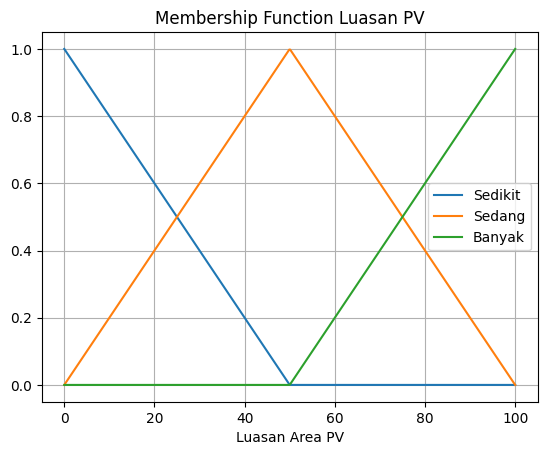

In [64]:
import matplotlib.pyplot as plt
import numpy as np

x_values = np.linspace(0, 100, 500)

#Luasan_PV function
luas_sedikit_vals = [Luasan_PV(val)[0] for val in x_values]
luas_sedang_vals = [Luasan_PV(val)[1] for val in x_values]
luas_banyak_vals = [Luasan_PV(val)[2] for val in x_values]

plt.plot(x_values, luas_sedikit_vals, label='Sedikit')
plt.plot(x_values, luas_sedang_vals, label='Sedang')
plt.plot(x_values, luas_banyak_vals, label='Banyak')

plt.title("Membership Function Luasan PV")
plt.xlabel("Luasan Area PV")
plt.legend()
plt.grid(True)
plt.show()

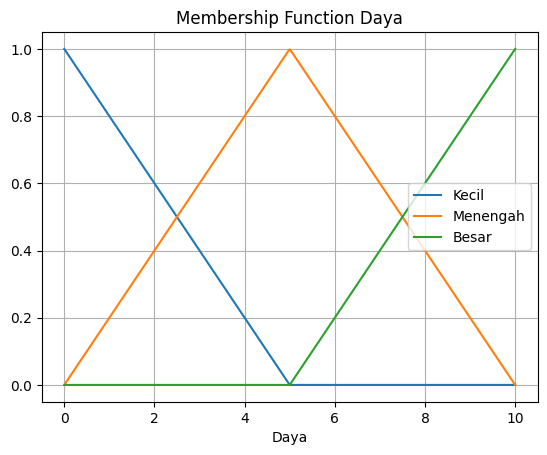

In [65]:
import matplotlib.pyplot as plt
import numpy as np

x_values = np.linspace(0, 10, 500)

#Daya_PV function
daya_kecil_vals = [daya_PV(val)[0] for val in x_values]
daya_menengah_vals = [daya_PV(val)[1] for val in x_values]
daya_besar_vals = [daya_PV(val)[2] for val in x_values]

plt.plot(x_values, daya_kecil_vals, label='Kecil')
plt.plot(x_values, daya_menengah_vals, label='Menengah')
plt.plot(x_values, daya_besar_vals, label='Besar')

plt.title("Membership Function Daya")
plt.xlabel("Daya")
plt.legend(loc="center right")
plt.grid(True)
plt.show()